<a href="https://colab.research.google.com/github/Tmiller68/machine-learning-fundamentals/blob/main/Day_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded=files.upload()

Saving adult.data to adult.data


In [8]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]



df = pd.read_csv(
    "adult.data",
    names=column_names,
    header=None)
df = df.replace(" ?", np.nan)
df = df.dropna()

In [9]:
X=df.drop("income", axis=1)
Y=df["income"].str.strip()
label_encoder=LabelEncoder()
Y=label_encoder.fit_transform(Y)

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [12]:
numeric_columns=X.select_dtypes(
    include=["int64", "float64"]
).columns
categorical_columns=X.select_dtypes(
    include=["object"]
).columns

In [13]:
print(numeric_columns)
print(categorical_columns)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country'],
      dtype='object')


In [14]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        numeric_columns
    ),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_columns
    )
])

In [15]:
adult_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

In [16]:
pipeline_scores = cross_val_score(
    adult_pipeline,
    X,
    Y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [17]:
print("Pipeline fold scores:")
print(pipeline_scores)

print(
    "Pipeline mean accuracy:",
    pipeline_scores.mean()
)

print(
    "Pipeline standard deviation:",
    pipeline_scores.std()
)

Pipeline fold scores:
[0.84485331 0.84253274 0.85029841 0.85344828 0.84864058]
Pipeline mean accuracy: 0.8479546622664647
Pipeline standard deviation: 0.0038770893237290312


In [18]:
leaky_preprocessor = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        numeric_columns
    ),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_columns
    )
])
X=leaky_preprocessor.fit_transform(X)

In [19]:
leaky_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

leaky_scores = cross_val_score(
    leaky_model,
    X,
    Y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [20]:
print("Leaked fold scores:")
print(leaky_scores)

print(
    "Leaked mean accuracy:",
    leaky_scores.mean()
)

print(
    "Leaked standard deviation:",
    leaky_scores.std()
)

Leaked fold scores:
[0.8445218  0.84253274 0.85013263 0.85311671 0.84864058]
Leaked mean accuracy: 0.8477888907648078
Leaked standard deviation: 0.003818512854146663


In [21]:
day4_results = pd.DataFrame({
    "Method": [
        "Leakage-Free Pipeline",
        "Preprocessing Before CV"
    ],
    "Mean CV Accuracy": [
        pipeline_scores.mean(),
        leaky_scores.mean()
    ],
    "Accuracy STD": [
        pipeline_scores.std(),
        leaky_scores.std()
    ]
})

day4_results

,Method,Mean CV Accuracy,Accuracy STD
0,Leakage-Free Pipeline,0.847955,0.003877
1,Preprocessing Before CV,0.847789,0.003819


In [22]:
day4_results["Mean CV Accuracy"] = (
    day4_results["Mean CV Accuracy"].round(4)
)

day4_results["Accuracy STD"] = (
    day4_results["Accuracy STD"].round(4)
)

day4_results

,Method,Mean CV Accuracy,Accuracy STD
0,Leakage-Free Pipeline,0.8480,0.0039
1,Preprocessing Before CV,0.8478,0.0038


Day 5

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        numeric_columns
    ),
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        categorical_columns
    )
])

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])

In [25]:
parameter_distributions = {
    "classifier__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "classifier__max_depth": [
        None,
        5,
        10,
        15,
        20
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4,
        8
    ]
}

In [26]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=parameter_distributions,
    n_iter=12,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

In [27]:
random_search.fit(
    X_train,
    Y_train
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               StandardScaler(),
                                                                               Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')),
                                                                              ('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country'],
      dtype='object'))])),
                                             ('classifier',
                                              RandomForestClassifier(n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [None, 5, 10,
                                                                  15, 20],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4, 8],
                                        'classifier__n_estimators': [100, 200,
                                                                     300,
                                                                     500]},
                   random_state=42, scoring='accuracy', verbose=1)

In [28]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation accuracy:")
print(random_search.best_score_)

Best parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 20}

Best cross-validation accuracy:
0.8591322306418816


In [29]:
best_random_forest = random_search.best_estimator_

In [30]:
from sklearn.metrics import accuracy_score

test_predictions = best_random_forest.predict(X_test)

test_accuracy = accuracy_score(
    Y_test,
    test_predictions
)

print("Final test accuracy:", test_accuracy)

Final test accuracy: 0.8577821979114868


In [33]:
from sklearn.inspection import permutation_importance
permutation_results = permutation_importance(
    best_random_forest,
    X_test,
    Y_test,
    scoring="accuracy",
    n_repeats=10,
    random_state=42,
    n_jobs=-1)

In [34]:
importance_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation_results.importances_mean,
    "Importance STD": permutation_results.importances_std
})

importance_table = importance_table.sort_values(
    by="Importance Mean",
    ascending=False
)

importance_table

,Feature,Importance Mean,Importance STD
10,capital_gain,0.037577,0.001214
5,marital_status,0.020935,0.001804
7,relationship,0.015349,0.001534
6,occupation,0.010061,0.002044
4,education_num,0.008835,0.003142
0,age,0.008089,0.001268
11,capital_loss,0.006697,0.000896
12,hours_per_week,0.004028,0.001447
9,sex,0.001906,0.000843
1,workclass,0.001160,0.000967


In [35]:
importance_table.head(10)

,Feature,Importance Mean,Importance STD
10,capital_gain,0.037577,0.001214
5,marital_status,0.020935,0.001804
7,relationship,0.015349,0.001534
6,occupation,0.010061,0.002044
4,education_num,0.008835,0.003142
0,age,0.008089,0.001268
11,capital_loss,0.006697,0.000896
12,hours_per_week,0.004028,0.001447
9,sex,0.001906,0.000843
1,workclass,0.001160,0.000967


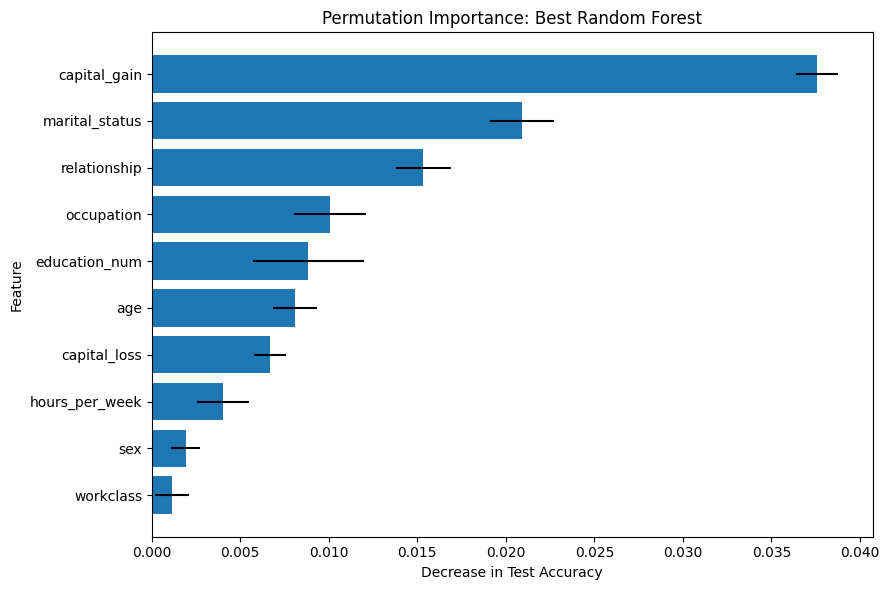

In [36]:
import matplotlib.pyplot as plt

top_features = importance_table.head(10).sort_values(
    by="Importance Mean",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance Mean"],
    xerr=top_features["Importance STD"]
)

plt.xlabel("Decrease in Test Accuracy")
plt.ylabel("Feature")
plt.title("Permutation Importance: Best Random Forest")
plt.tight_layout()
plt.show()

In [37]:
random_forest_classifier = (
    best_random_forest.named_steps["classifier"]
)

impurity_importances = (
    random_forest_classifier.feature_importances_
)